In [1]:
!pip install pandas matplotlib seaborn sweetviz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.1/15.1 MB 76.9 MB/s eta 0:00:00


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/content/Customer Dataset.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [4]:
display(df)

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0
...,...,...,...,...,...,...,...,...,...,...,...,...
64369,64370,45,Female,33,12,6,21,Basic,Quarterly,947,14,1
64370,64371,37,Male,6,1,5,22,Standard,Annual,923,9,1
64371,64372,25,Male,39,14,8,30,Premium,Monthly,327,20,1
64372,64373,50,Female,18,19,7,22,Standard,Monthly,540,13,1


In [3]:

df.head(10)

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0
5,6,30,Male,41,14,10,10,Premium,Monthly,500,29,0
6,7,47,Female,37,15,9,28,Basic,Quarterly,574,14,1
7,8,54,Female,36,11,0,18,Standard,Monthly,323,16,0
8,9,36,Male,20,5,10,8,Basic,Monthly,687,8,0
9,10,65,Male,8,4,2,23,Basic,Annual,995,10,0


In [7]:

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 64374
Number of columns: 12


In [8]:

print(df.columns)

print("\nColumn names and data types:")
df.info()

Index(['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage Frequency',
       'Support Calls', 'Payment Delay', 'Subscription Type',
       'Contract Length', 'Total Spend', 'Last Interaction', 'Churn'],
      dtype='object')

Column names and data types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64374 entries, 0 to 64373
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   CustomerID         64374 non-null  int64 
 1   Age                64374 non-null  int64 
 2   Gender             64374 non-null  object
 3   Tenure             64374 non-null  int64 
 4   Usage Frequency    64374 non-null  int64 
 5   Support Calls      64374 non-null  int64 
 6   Payment Delay      64374 non-null  int64 
 7   Subscription Type  64374 non-null  object
 8   Contract Length    64374 non-null  object
 9   Total Spend        64374 non-null  int64 
 10  Last Interaction   64374 non-null  int64 
 11  Churn              6437

In [10]:

print(df.isnull().sum())

CustomerID           0
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64


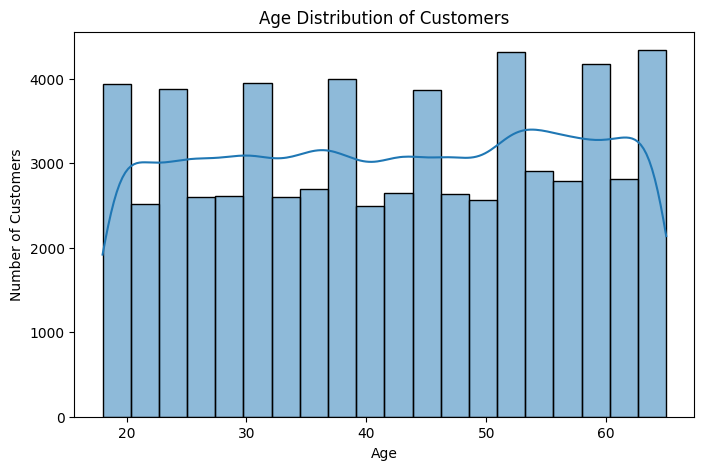

In [11]:

plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="Age", bins=20, kde=True)

plt.title("Age Distribution of Customers")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.show()

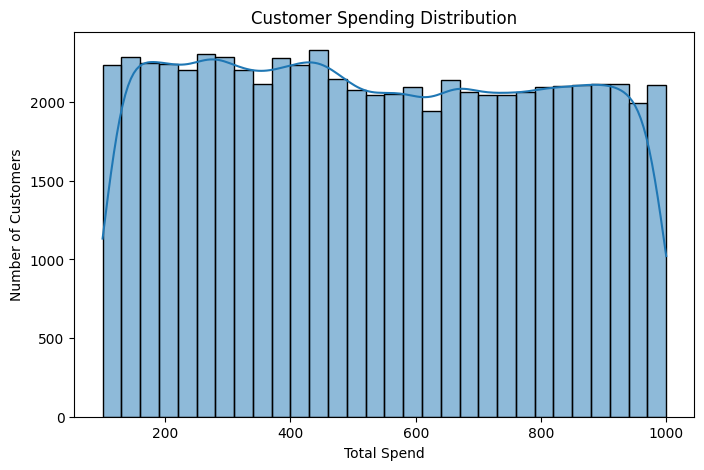

In [13]:

plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="Total Spend", bins=30, kde=True)

plt.title("Customer Spending Distribution")
plt.xlabel("Total Spend")
plt.ylabel("Number of Customers")

plt.show()

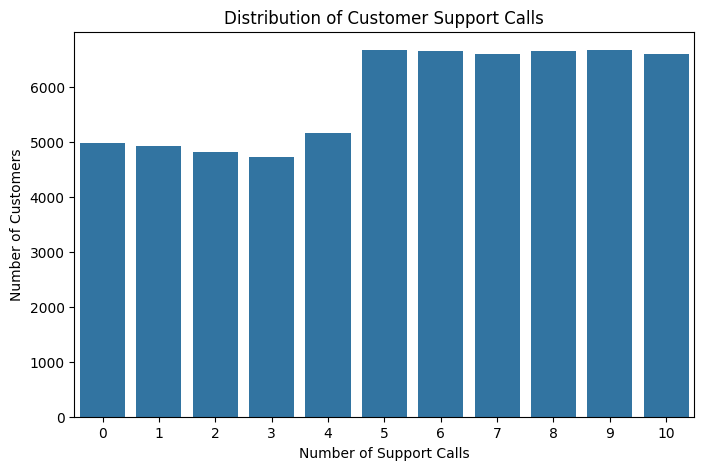

In [12]:

plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="Support Calls")

plt.title("Distribution of Customer Support Calls")
plt.xlabel("Number of Support Calls")
plt.ylabel("Number of Customers")

plt.show()

In [14]:

churn_subscription = pd.crosstab(
    df["Subscription Type"],
    df["Churn"]
)

print(churn_subscription)

Churn                  0      1
Subscription Type              
Basic              11095  10356
Premium            11461   9960
Standard           11325  10177


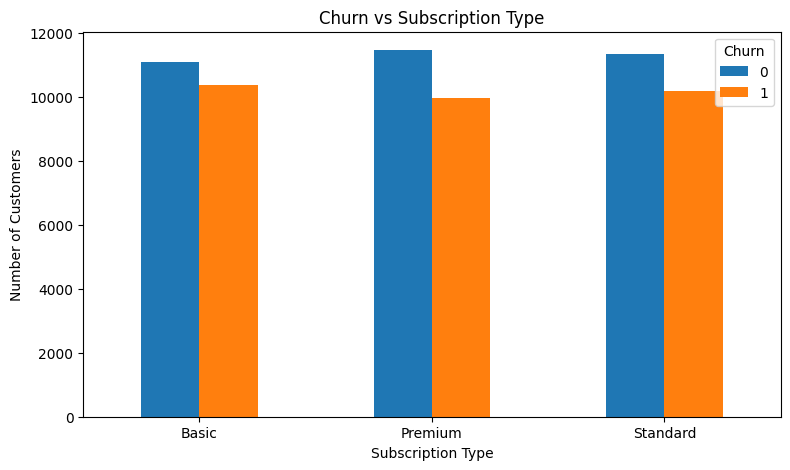

In [15]:

churn_subscription.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Churn vs Subscription Type")
plt.xlabel("Subscription Type")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.legend(title="Churn")

plt.show()

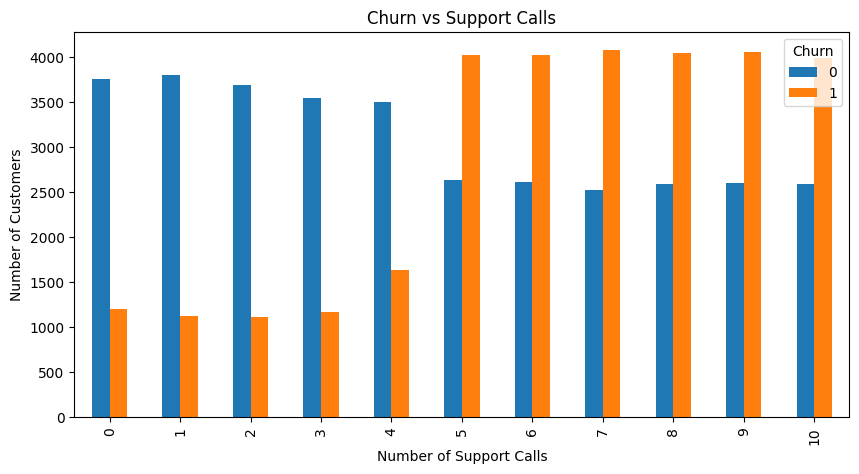

In [18]:

churn_support = pd.crosstab(
    df["Support Calls"],
    df["Churn"]
)

churn_support.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Churn vs Support Calls")
plt.xlabel("Number of Support Calls")
plt.ylabel("Number of Customers")
plt.legend(title="Churn")

plt.show()

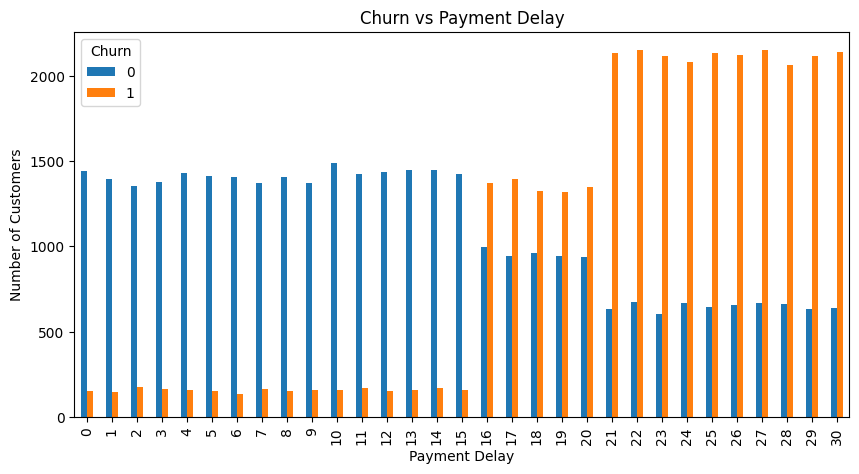

In [24]:


# Create the summary table
churn_payment = pd.crosstab(
    df["Payment Delay"],
    df["Churn"]
)

churn_payment.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Churn vs Payment Delay")
plt.xlabel("Payment Delay")
plt.ylabel("Number of Customers")
plt.legend(title="Churn")

plt.show()

In [4]:

print(df["Churn"].value_counts(dropna=False))

Churn
0    33881
1    30493
Name: count, dtype: int64


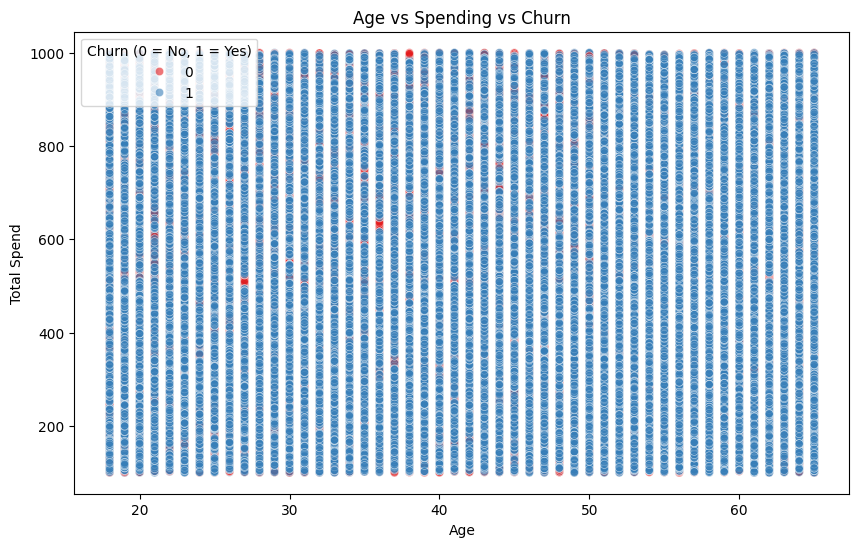

In [14]:

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Age",
    y="Total Spend",
    hue="Churn_Flag",
    palette="Set1",
    alpha=0.6
)

plt.title("Age vs Spending vs Churn")
plt.xlabel("Age")
plt.ylabel("Total Spend")
plt.legend(title="Churn (0 = No, 1 = Yes)")

plt.show()

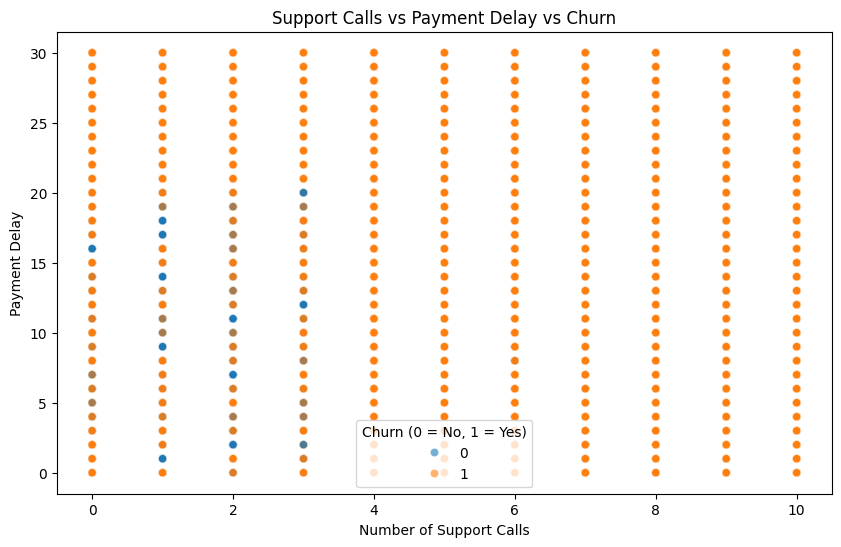

In [15]:

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Support Calls",
    y="Payment Delay",
    hue="Churn_Flag",
    alpha=0.6
)

plt.title("Support Calls vs Payment Delay vs Churn")
plt.xlabel("Number of Support Calls")
plt.ylabel("Payment Delay")
plt.legend(title="Churn (0 = No, 1 = Yes)")

plt.show()

In [17]:

!pip install sweetviz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.1/15.1 MB 76.0 MB/s eta 0:00:00


In [18]:

import sweetviz as sv

In [19]:

report = sv.analyze(df)

report.show_html("customer_churn_report.html")

                                             |          | [  0%]   00:00 -> (? left)

Report customer_churn_report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


In [20]:

from google.colab import files

files.download("customer_churn_report.html")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [21]:

report = sv.compare_intra(
    df,
    df["Churn_Flag"] == 1,
    ["Churned Customers", "Non-Churned Customers"]
)

report.show_html("churn_comparison_report.html")

                                             |          | [  0%]   00:00 -> (? left)

Report churn_comparison_report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


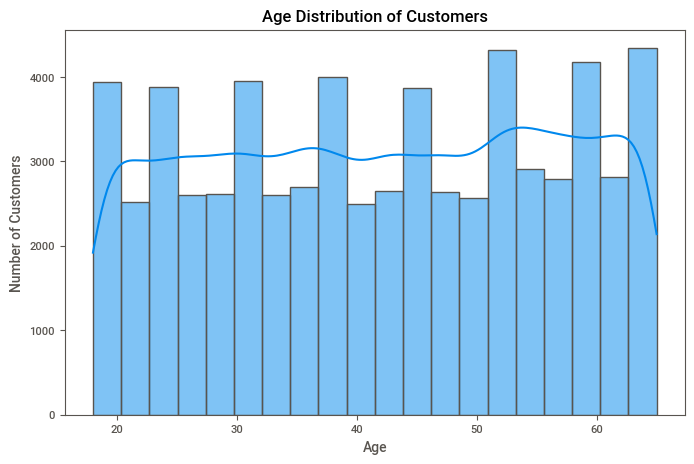

In [22]:

plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="Age", bins=20, kde=True)

plt.title("Age Distribution of Customers")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.savefig("age_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [23]:

files.download("age_distribution.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>